# Black Swan V3 - Modelare Binary Classification
**Target:** 1 = V-shape (recuperare >5% in 60 zile), 0 = Non-V  
**Nou fata de V2:** ROC AUC ca metrica principala, threshold optimization, class_weight balanced

## 1. Import si Incarcare Date

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes   import GaussianNB
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.ensemble      import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score
)
from xgboost import XGBClassifier

os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

train_df = pd.read_csv('v3_train.csv', index_col=0, parse_dates=True)
test_df  = pd.read_csv('v3_test.csv',  index_col=0, parse_dates=True)

with open('v3_feature_cols.json') as f:
    feature_cols = json.load(f)

print('Train:', len(train_df), '| Test:', len(test_df))
print('Features:', len(feature_cols))

Train: 1646 | Test: 735
Features: 16


## 2. Pregatire X / y si Scalare

In [3]:
X_train_raw = train_df[feature_cols]
y_train     = train_df['label']
X_test_raw  = test_df[feature_cols]
y_test      = test_df['label']

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print('Scalare completata.')
print('Distributie y_train: Non-V =', (y_train==0).sum(), '| V-shape =', (y_train==1).sum())
print('Distributie y_test:  Non-V =', (y_test==0).sum(),  '| V-shape =', (y_test==1).sum())

Scalare completata.
Distributie y_train: Non-V = 1185 | V-shape = 461
Distributie y_test:  Non-V = 512 | V-shape = 223


## 3. Antrenare Algoritmi

`class_weight='balanced'` compenseaza dezechilibrul 71/29.  
Fara el, modelele ar invata sa zica aproape mereu Non-V si ar avea accuracy ridicata dar inutila.

In [4]:
models = {
    'Naive Bayes'   : GaussianNB(),
    'KNN'           : KNeighborsClassifier(n_neighbors=15, metric='euclidean'),
    'Random Forest' : RandomForestClassifier(
                          n_estimators=200, max_depth=6,
                          class_weight='balanced', random_state=42
                      ),
    'XGBoost'       : XGBClassifier(
                          n_estimators=200, max_depth=4, learning_rate=0.05,
                          eval_metric='logloss', random_state=42,
                          scale_pos_weight=(y_train==0).sum() / (y_train==1).sum()
                      )
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'model'  : model,
        'y_pred' : y_pred,
        'y_proba': y_proba,
        'acc'    : acc,
        'auc'    : auc
    }

    print(name.ljust(20), 'Accuracy:', round(acc, 3), '| ROC AUC:', round(auc, 3))

print('\nAntrenare completa.')

Naive Bayes          Accuracy: 0.626 | ROC AUC: 0.705
KNN                  Accuracy: 0.691 | ROC AUC: 0.651
Random Forest        Accuracy: 0.676 | ROC AUC: 0.678
XGBoost              Accuracy: 0.675 | ROC AUC: 0.663

Antrenare completa.


## 4. Classification Report

In [5]:
separator = '=' * 50

for name, res in results.items():
    print(separator)
    print(name)
    print(separator)
    print(classification_report(y_test, res['y_pred'], target_names=['Non-V (0)', 'V-shape (1)']))
    print()

Naive Bayes
              precision    recall  f1-score   support

   Non-V (0)       0.79      0.63      0.70       512
 V-shape (1)       0.42      0.61      0.50       223

    accuracy                           0.63       735
   macro avg       0.60      0.62      0.60       735
weighted avg       0.68      0.63      0.64       735


KNN
              precision    recall  f1-score   support

   Non-V (0)       0.74      0.85      0.79       512
 V-shape (1)       0.49      0.33      0.39       223

    accuracy                           0.69       735
   macro avg       0.62      0.59      0.59       735
weighted avg       0.67      0.69      0.67       735


Random Forest
              precision    recall  f1-score   support

   Non-V (0)       0.78      0.75      0.76       512
 V-shape (1)       0.47      0.52      0.49       223

    accuracy                           0.68       735
   macro avg       0.62      0.63      0.63       735
weighted avg       0.69      0.68      0.6

## 5. ROC Curves

**Cum se citeste ROC Curve:**  
- Axa X = False Positive Rate (cat de des zicem V-shape cand nu e)  
- Axa Y = True Positive Rate (cat de des prindem V-shape-urile reale)  
- **AUC = aria sub curba.** 1.0 = perfect, 0.5 = random (linia diagonala)  
- Cu cat curba e mai sus si mai la stanga, cu atat modelul e mai bun

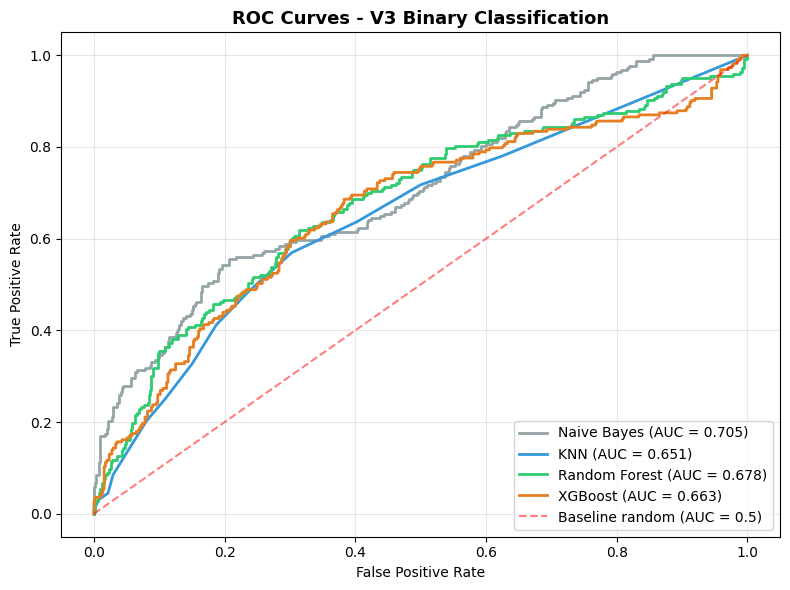

Salvat: plots/v3_roc_curves.png


In [6]:
colors = ['#95a5a6', '#3498db', '#2ecc71', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=name + ' (AUC = ' + str(round(res['auc'], 3)) + ')')

ax.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Baseline random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - V3 Binary Classification', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/v3_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/v3_roc_curves.png')

## 6. Threshold Optimization

**De ce optimizam threshold-ul?**  
Implicit modelul zice V-shape daca probabilitatea > 0.5.  
Dar 0.5 nu e neaparat optim pe date dezechilibrate.  
Gasim threshold-ul care maximizeaza F1-score pentru V-shape pe setul de test.

Model selectat pentru threshold optimization: Naive Bayes
Threshold optim: 0.82
F1 V-shape la threshold optim: 0.545
F1 V-shape la threshold 0.5:   0.499


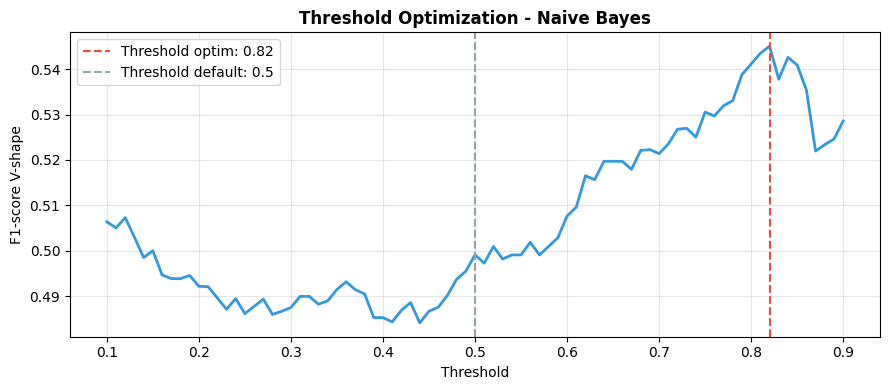

Salvat: plots/v3_threshold_optimization.png


In [7]:
best_model_name = max(results, key=lambda n: results[n]['auc'])
best_proba      = results[best_model_name]['y_proba']

print('Model selectat pentru threshold optimization:', best_model_name)

# Testam toate threshold-urile intre 0.1 si 0.9
thresholds = np.arange(0.10, 0.91, 0.01)
f1_scores  = []

for t in thresholds:
    y_pred_t = (best_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, pos_label=1, zero_division=0))

optimal_threshold = thresholds[np.argmax(f1_scores)]
optimal_f1        = max(f1_scores)

print('Threshold optim:', round(optimal_threshold, 2))
print('F1 V-shape la threshold optim:', round(optimal_f1, 3))
print('F1 V-shape la threshold 0.5:  ', round(f1_scores[list(thresholds.round(2)).index(0.50)], 3))

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores, color='#3498db', linewidth=2)
ax.axvline(optimal_threshold, color='#e74c3c', linestyle='--',
           label='Threshold optim: ' + str(round(optimal_threshold, 2)))
ax.axvline(0.5, color='#95a5a6', linestyle='--', label='Threshold default: 0.5')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1-score V-shape')
ax.set_title('Threshold Optimization - ' + best_model_name, fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/v3_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/v3_threshold_optimization.png')

## 7. Confusion Matrices cu Threshold Optim

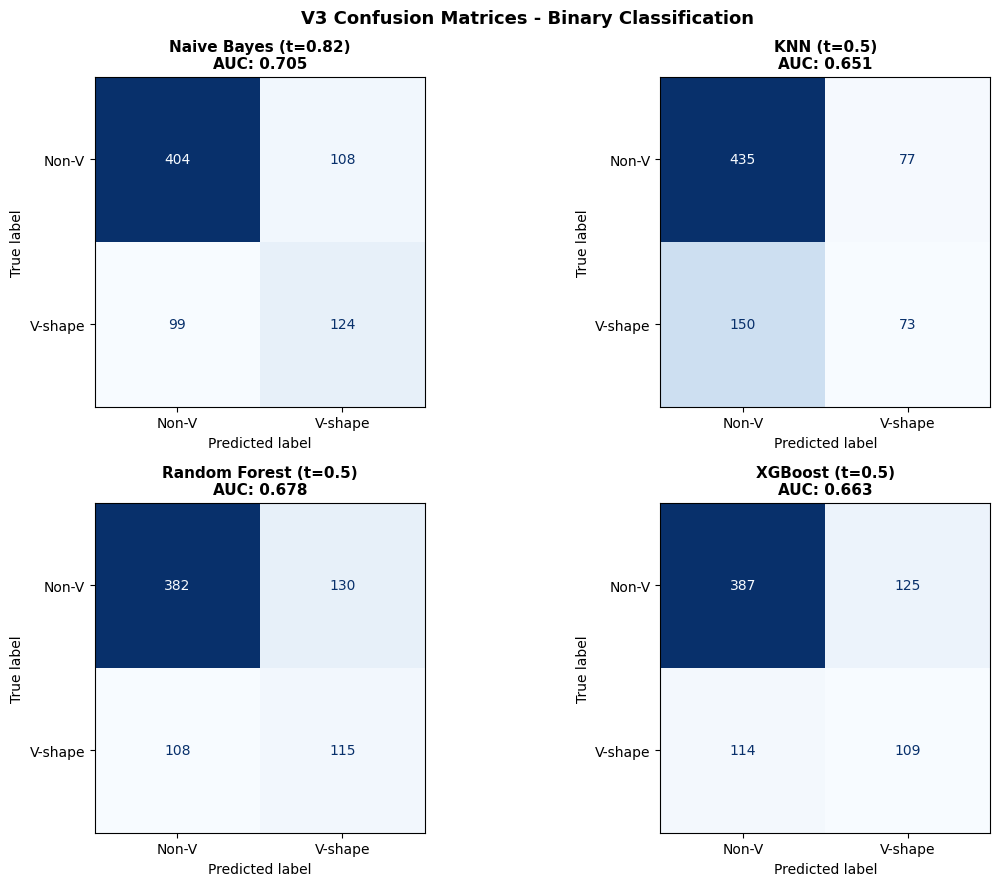

Salvat: plots/v3_confusion_matrices.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    # Folosim threshold optim pentru cel mai bun model, 0.5 pentru restul
    if name == best_model_name:
        y_pred_opt = (res['y_proba'] >= optimal_threshold).astype(int)
        title_suffix = ' (t=' + str(round(optimal_threshold, 2)) + ')'
    else:
        y_pred_opt   = res['y_pred']
        title_suffix = ' (t=0.5)'

    cm   = confusion_matrix(y_test, y_pred_opt)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-V', 'V-shape'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(
        name + title_suffix + '\nAUC: ' + str(round(res['auc'], 3)),
        fontsize=11, fontweight='bold'
    )

plt.suptitle('V3 Confusion Matrices - Binary Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/v3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/v3_confusion_matrices.png')

## 8. Probabilitati per Eveniment de Test

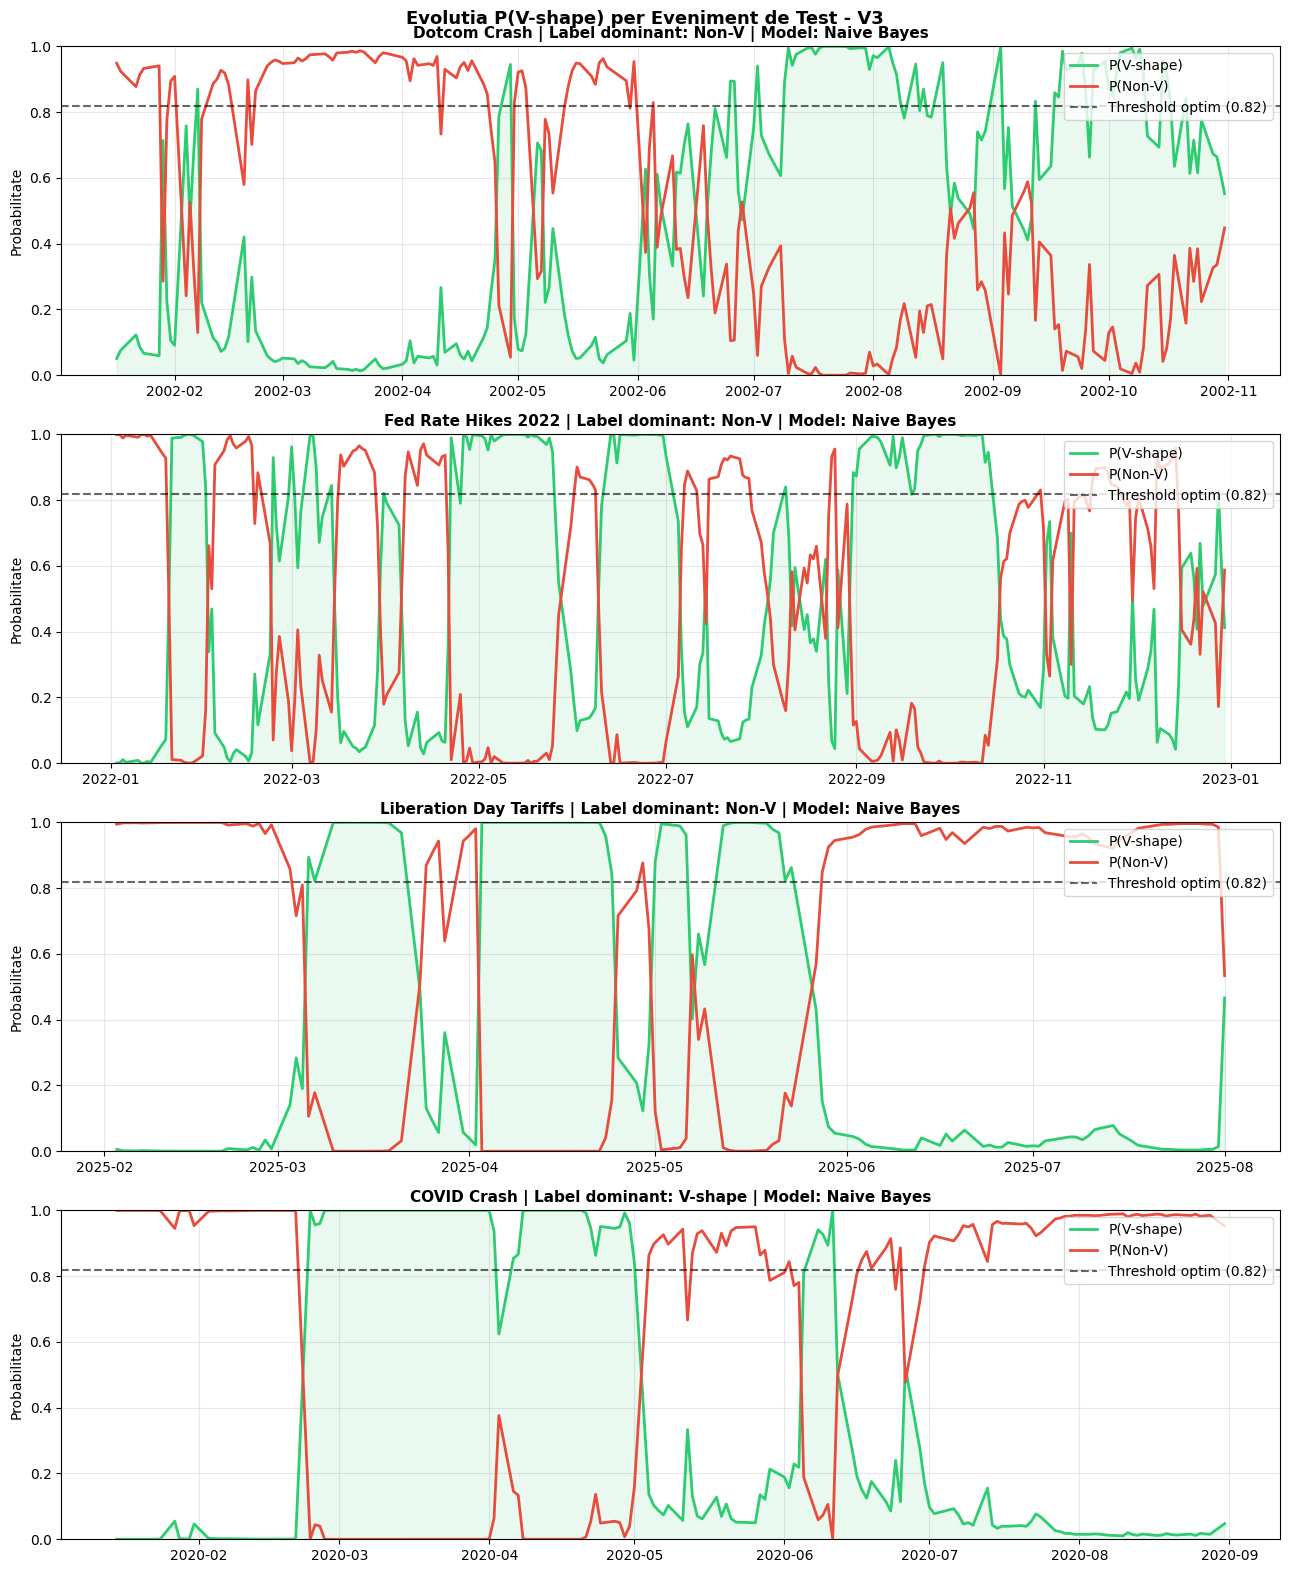

Salvat: plots/v3_probabilities_per_event.png


In [9]:
best_model  = results[best_model_name]['model']
best_proba  = results[best_model_name]['y_proba']

proba_df = pd.DataFrame({
    'P_VShape'   : best_proba,
    'P_NonV'     : 1 - best_proba,
    'event_name' : test_df['event_name'].values,
    'true_label' : test_df['label'].values
}, index=test_df.index)

test_event_names = test_df['event_name'].unique()

fig, axes = plt.subplots(len(test_event_names), 1, figsize=(13, 4 * len(test_event_names)))

if len(test_event_names) == 1:
    axes = [axes]

for ax, event in zip(axes, test_event_names):
    ev = proba_df[proba_df['event_name'] == event]
    true_lbl = 'V-shape' if ev['true_label'].mode()[0] == 1 else 'Non-V'

    ax.plot(ev.index, ev['P_VShape'], color='#2ecc71', linewidth=2, label='P(V-shape)')
    ax.plot(ev.index, ev['P_NonV'],   color='#e74c3c', linewidth=2, label='P(Non-V)')
    ax.axhline(optimal_threshold, color='black', linestyle='--', alpha=0.6,
               label='Threshold optim (' + str(round(optimal_threshold, 2)) + ')')
    ax.fill_between(ev.index, ev['P_VShape'], alpha=0.1, color='#2ecc71')

    ax.set_title(
        event + ' | Label dominant: ' + true_lbl + ' | Model: ' + best_model_name,
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel('Probabilitate')
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Evolutia P(V-shape) per Eveniment de Test - V3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/v3_probabilities_per_event.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/v3_probabilities_per_event.png')

## 9. Feature Importance

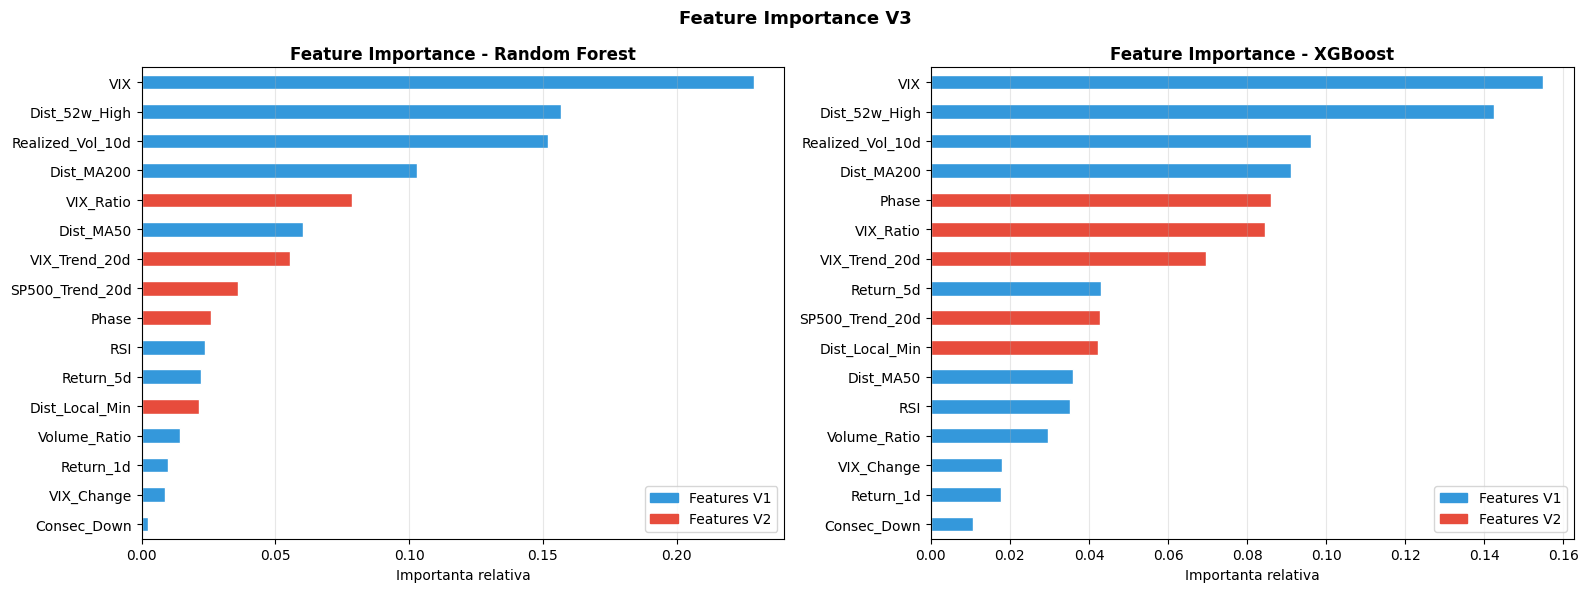

Salvat: plots/v3_feature_importance.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
new_features = ['VIX_Trend_20d', 'SP500_Trend_20d', 'Dist_Local_Min', 'VIX_Ratio', 'Phase']

from matplotlib.patches import Patch

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
    importances = pd.Series(
        results[model_name]['model'].feature_importances_,
        index=feature_cols
    ).sort_values(ascending=True)

    bar_colors = ['#e74c3c' if f in new_features else '#3498db' for f in importances.index]
    importances.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
    ax.set_title('Feature Importance - ' + model_name, fontweight='bold')
    ax.set_xlabel('Importanta relativa')
    ax.grid(True, axis='x', alpha=0.3)
    legend = [Patch(color='#3498db', label='Features V1'), Patch(color='#e74c3c', label='Features V2')]
    ax.legend(handles=legend, loc='lower right')

plt.suptitle('Feature Importance V3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/v3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/v3_feature_importance.png')

## 10. Salvare Model pentru Dashboard

In [11]:
pickle.dump(best_model,        open('models/v3_best_model.pkl', 'wb'))
pickle.dump(scaler,            open('models/v3_scaler.pkl',     'wb'))

meta = {
    'model_name'        : best_model_name,
    'auc'               : round(results[best_model_name]['auc'], 4),
    'accuracy'          : round(results[best_model_name]['acc'], 4),
    'optimal_threshold' : round(float(optimal_threshold), 2),
    'feature_cols'      : feature_cols,
    'v_threshold'       : 0.05,
    'forward_days'      : 60,
    'classes'           : {0: 'Non-V', 1: 'V-shape'}
}
with open('models/v3_model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Fisiere salvate in models/:')
print('  v3_best_model.pkl')
print('  v3_scaler.pkl')
print('  v3_model_meta.json')
print('\nModel:', best_model_name)
print('AUC:  ', round(results[best_model_name]['auc'], 4))
print('Threshold optim:', round(float(optimal_threshold), 2))

Fisiere salvate in models/:
  v3_best_model.pkl
  v3_scaler.pkl
  v3_model_meta.json

Model: Naive Bayes
AUC:   0.7045
Threshold optim: 0.82


## 11. Rezumat Final V1 vs V2 vs V3

In [12]:
separator = '=' * 55
print('REZUMAT COMPARATIV')
print(separator)

v1_acc = {'Naive Bayes': 0.434, 'KNN': 0.522, 'Random Forest': 0.415, 'XGBoost': 0.431}
v2_acc = {'Naive Bayes': 0.314, 'KNN': 0.495, 'Random Forest': 0.471, 'XGBoost': 0.466}

rows = []
for name in results:
    rows.append({
        'Model'   : name,
        'V1 Acc'  : v1_acc[name],
        'V2 Acc'  : v2_acc[name],
        'V3 Acc'  : round(results[name]['acc'], 3),
        'V3 AUC'  : round(results[name]['auc'], 3)
    })

summary = pd.DataFrame(rows).sort_values('V3 AUC', ascending=False).reset_index(drop=True)
summary.index += 1
print(summary.to_string())

print('\nCel mai bun model V3:', best_model_name)
print('AUC:', round(results[best_model_name]['auc'], 4))
print('Threshold optim:', round(float(optimal_threshold), 2))
print('\nGata pentru dashboard.')

REZUMAT COMPARATIV
           Model  V1 Acc  V2 Acc  V3 Acc  V3 AUC
1    Naive Bayes   0.434   0.314   0.626   0.705
2  Random Forest   0.415   0.471   0.676   0.678
3        XGBoost   0.431   0.466   0.675   0.663
4            KNN   0.522   0.495   0.691   0.651

Cel mai bun model V3: Naive Bayes
AUC: 0.7045
Threshold optim: 0.82

Gata pentru dashboard.
